# CME538 - Introduction to Data Science

## Assignment 2 - Data Wrangling

### Learning Objectives

After completing this assignment, you should be able to:

- Retrieve and parse structured information from HTML using `requests` and `BeautifulSoup`.
- Transform semi-structured text data into Pandas DataFrames.
- Write a reusable function to parse repeated records from text files.
- Combine data from multiple files using iteration and `pd.concat()`.
- Merge DataFrames using common identifiers.
- Apply functions to DataFrame rows to create derived variables.
- Filter and summarize data to answer an engineering question.
- Write clear, concise, and reproducible data-wrangling code.

### Submission Guidelines

You may add additional cells for exploratory or scratch work while completing the assignment. Before submitting:

- Remove unnecessary scratch cells and outputs.
- Keep only the code and output needed to answer each question.
- Do not display entire DataFrames or large outputs unless explicitly requested.
- Use the variable names specified in each question.
- Restart the kernel and run the notebook from beginning to end to ensure that all cells execute without errors.

### Marking Breakdown

| Component | Points |
|---|---:|
| Question 1a | 1 |
| Question 1b | 4 |
| Question 1c | 1 |
| Question 2a | 5 |
| Question 2b | 2 |
| Question 2c | 1 |
| Question 2d | 1 |
| Question 2e | 1 |
| Question 2f | 1 |
| Question 2g | 1 |
| Question 2h | 1 |
| Code Quality | 3 |
| **Total** | **22** |

### Code Quality

Code quality will be assessed across the complete notebook.

| Level | Points | Description |
|---|---:|---|
| **Developing** | 1 | Code produces the required results but may be difficult to follow, unnecessarily repetitive, poorly organized, or include excessive output. |
| **Competent** | 2 | Code is organized and readable, uses appropriate Python and Pandas operations, and produces concise, relevant outputs. |
| **Strong** | 3 | Code is clear, concise, well organized, and reproducible; uses Python and Pandas effectively; avoids unnecessary operations and output; and executes successfully from beginning to end. |

## Notebook Setup

In [ ]:
# Import required libraries
import os
import requests
import pandas as pd
from bs4 import BeautifulSoup

# Import course utilities
import utils

# Overview

You have joined an engineering team planning a new waterfront facility on Lake Ontario. As part of the preliminary design process, the team needs information about local wave conditions, including wave height and direction.

In this assignment, you will work with data from the **NOAA Great Lakes Environmental Research Laboratory (GLERL)**. The GLERL archive contains forecasts and measurements for several environmental variables across the Great Lakes, including wave height, wave direction, wind speed, currents, and ice cover.

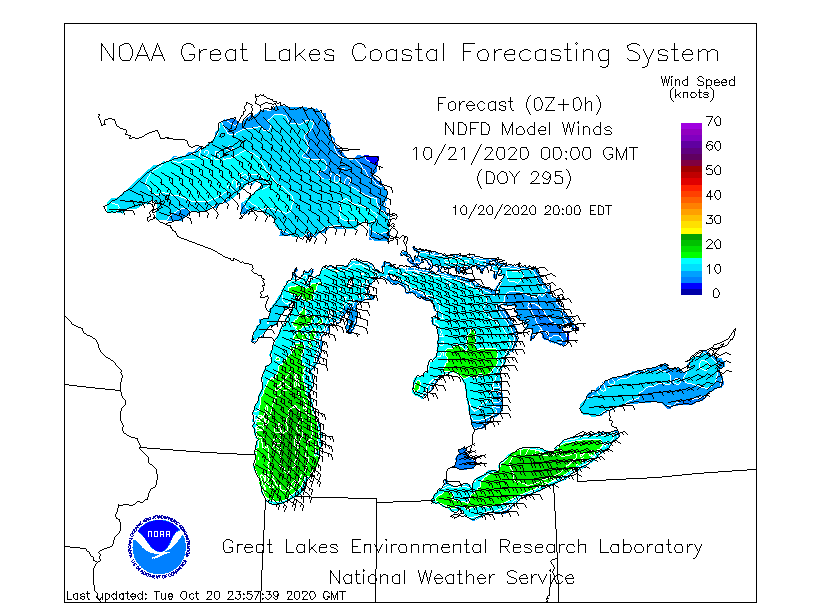

Your task is to build a data-wrangling workflow that:

1. identifies relevant Lake Ontario wave-data files,
2. parses wave measurements from semi-structured text files,
3. combines the measurements with geographic grid information,
4. identifies the three grid points closest to the proposed facility, and
5. summarizes the minimum, maximum, and average wave height observed at those locations.

The proposed facility is located at:

- Latitude: `43.9593`
- Longitude: `-78.1677`

This assignment focuses on transforming raw environmental data into a structured dataset that can support an engineering decision.

---

## Question 1 - HTML Parsing

In Question 1, you will extract file information from a saved HTML directory listing from the NOAA Great Lakes Environmental Research Laboratory (GLERL) archive.

The provided file, `noaa_archive_2021.html`, contains a snapshot of the 2021 GLERL wave-data directory. You will use `BeautifulSoup` to parse the HTML and organize information about the available files into a Pandas DataFrame.

The filenames follow the general format:

`LYYYY_MM.F.NC`

where:

- `L` = lake identifier (`c` = St. Clair, `s` = Superior, `m` = Michigan, `h` = Huron, `e` = Erie, `o` = Ontario)
- `YYYY` = year
- `MM` = month
- `F` = file type (`in1` or `out1`)
- `NC` = NetCDF file extension

For example, `o2021_05.in1.nc` contains Lake Ontario data beginning in May 2021.

---

### Question 1a - Parsing the HTML

Read the provided `noaa_archive_2021.html` file and parse its contents using `BeautifulSoup`.

Extract all HTML table rows (`<tr>`) and store them in a variable named `table_rows`.

Remove any non-data rows so that `table_rows` contains only rows corresponding to NOAA data files.

In [ ]:
# Read and parse the saved NOAA HTML directory
with open("noaa_archive_2021.html", "r", encoding="utf-8") as file:
    html = file.read()

soup = ...

# Extract and clean the table rows
table_rows = ...

# Display the number of data rows
print(f"Number of NOAA data rows: {len(table_rows)}")

#### Question 1a - Answer

- Number of NOAA data rows: **[Your answer here]**

---

### Question 1b - Building a File Metadata DataFrame

Use `table_rows` to create a Pandas DataFrame named `noaa_files`.

The DataFrame should contain one row for each NOAA data file and the following columns:

- `filename`
- `upload_date`
- `file_size`

Extract these values from the HTML contained in `table_rows`.

Clean the extracted text so that leading and trailing whitespace is removed from each value.

Your final `noaa_files` DataFrame should contain **54 rows and 3 columns**.

In [ ]:
# Extract file metadata from the HTML table rows
...

# Create the DataFrame
noaa_files = ...

# Preview the first five rows
noaa_files.head()

In [ ]:
print(f"noaa_files shape: {noaa_files.shape}")

#### Question 1b - Answer

Using `noaa_files`, report the upload date and file size for `c2021_07.in1.nc`.

- Upload date: **[Your answer here]**
- File size: **[Your answer here]**

---

### Question 1c - Filtering File Metadata

Filter `noaa_files` to retain only the `.in1.nc` files for **Lake Ontario**.

After filtering, reset the DataFrame index using `.reset_index(drop=True)`.

In [ ]:
# Filter for Lake Ontario .in1.nc files and reset the index
noaa_files = ...

# Preview the filtered DataFrame
noaa_files.head()

In [ ]:
# Display the number of retained files
print(f"Number of Lake Ontario files: {noaa_files.shape[0]}")

#### Question 1c - Answer

- Number of Lake Ontario `.in1.nc` files: **[Your answer here]**

---
---

## Question 2 - Parsing and Combining Wave Data

In Question 2, you will work with a collection of NOAA `.wav` files provided in the assignment directory. These files contain wave measurements recorded at grid points across Lake Ontario.

The wave-data filenames follow the format:

`LYYYYDDDHH.N.wav`

where:

- `L` = lake identifier (`s` = Superior, `m` = Michigan, `h` = Huron, `e` = Erie, `o` = Ontario)
- `YYYY` = year at the start of the simulation (GMT)
- `DDD` = day of year
- `HH` = hour at the start of the simulation (GMT)
- `N` = site number

Because this assignment focuses on Lake Ontario, the provided files follow the format:

`oYYYYDDDHH.0.wav`

For example, `o202101518.0.wav` represents a Lake Ontario wave-data file from 2021.

A reference file named `noaa_files.csv` is provided and contains the filenames of the `.wav` files used in this question.

In [ ]:
# Load the reference list of NOAA wave-data files
noaa_files = pd.read_csv("noaa_files.csv")

# Preview the first five rows
noaa_files.head()

In [ ]:
# Display the number of files listed in the reference DataFrame
print(f"Number of wave-data files: {noaa_files.shape[0]}")

The `noaa_files` DataFrame contains **32 filenames**, corresponding to the 32 `.wav` files provided with the assignment.

---

### Question 2a - Parsing a Wave-Data File

Write a function named `noaa_file_parser(filename)` that reads a NOAA `.wav` file and returns its wave measurements as a Pandas DataFrame.

The returned DataFrame must contain the following columns:

| Column | Data type | Description |
|---|---|---|
| `filename` | string | Source filename |
| `year` | int | Year of measurement |
| `day` | int | Day of year |
| `hour` | int | Hour of measurement (GMT) |
| `grid_number` | int | NOAA grid-point identifier |
| `wave_height` | float | Wave height in metres |
| `wave_direction` | int | Wave direction in degrees |
| `wave_period` | float | Wave period in seconds |

Each file contains two types of rows.

**Timestamp rows** identify the date and time associated with the measurements that follow. For example:

`2021 015 19     /glcfs/bathy/ontario5km.dat    WAVES    746`

The relevant values are:

- `2021` - year
- `015` - day of year
- `19` - hour

**Measurement rows** contain measurements for individual grid points. For example:

`1   1.029   231   4.2`

The four values represent:

- `1` - grid number
- `1.029` - wave height (m)
- `231` - wave direction (degrees)
- `4.2` - wave period (s)

A timestamp row is followed by the measurement rows associated with that timestamp. This pattern repeats throughout the file.

Your function should keep track of the current timestamp and associate it with each measurement row that follows.

In [ ]:
# Inspect the first 10 lines of one wave-data file
with open("o202101518.0.wav", "r") as file:
    sample_lines = file.read().splitlines()[:10]

sample_lines

In [ ]:
# Define a function to parse a NOAA wave-data file
def noaa_file_parser(filename):
    ...

# Parse the first file in the reference DataFrame
file_grid_data = noaa_file_parser(noaa_files.loc[0, "filename"])

# Preview the parsed data
file_grid_data.head()

In [ ]:
# Display the dimensions of the parsed DataFrame
print(f"file_grid_data shape: {file_grid_data.shape}")

#### Question 2a - Answer

Using the first row of `file_grid_data`, report:

- Year: **[Your answer here]**
- Day of year: **[Your answer here]**
- Hour: **[Your answer here]**
- Grid number: **[Your answer here]**
- Wave height: **[Your answer here]**
- Wave direction: **[Your answer here]**
- Wave period: **[Your answer here]**

---

### Question 2b - Combining Multiple Wave-Data Files

Use your `noaa_file_parser()` function to parse all `.wav` files listed in `noaa_files`.

1. Create an empty list.
2. Loop through the filenames in `noaa_files["filename"]`.
3. Apply `noaa_file_parser()` to each file and append the returned DataFrame to the list.
4. Use `pd.concat()` to combine the DataFrames into a single DataFrame.

Store the final combined DataFrame in a variable named `grid_data`.

Reset the index of the combined DataFrame.

In [ ]:
# Parse each NOAA file and store the resulting DataFrames
...

# Combine the parsed DataFrames
grid_data = ...

# Preview the combined data
grid_data.head()

In [ ]:
# Display the number of source files and rows in the combined DataFrame
print(f"Unique files: {grid_data['filename'].nunique()}")
print(f"Number of rows: {grid_data.shape[0]}")

#### Question 2b - Answer

- Number of unique source files in `grid_data`: **[Your answer here]**
- Number of rows in `grid_data`: **[Your answer here]**

---

### Question 2c - Loading Grid Location Data

The provided `ontario5km.map` file contains geographic information for each `grid_number` in the Lake Ontario wave dataset.

The file is whitespace-delimited and does not contain a header row. Its six fields are:

| Field | Description |
|---|---|
| `grid_number` | Grid-point identifier |
| `fortran_column` | Fortran grid column |
| `fortran_row` | Fortran grid row |
| `lat` | Latitude in decimal degrees north |
| `lon` | Longitude in decimal degrees west |
| `depth` | Water depth in metres |

Read `ontario5km.map` into a Pandas DataFrame named `map_file` and assign the column names shown above.

Because longitude values in the source file are expressed as degrees west, convert the `lon` values to negative decimal degrees.

In [ ]:
# Inspect the first five lines of the map file
with open("ontario5km.map", "r") as file:
    print("".join(file.readlines()[:5]))

In [ ]:
# Load the whitespace-delimited grid location data
map_file = ...

# Convert longitude from degrees west to negative decimal degrees
map_file["lon"] = ...

# Preview the DataFrame
map_file.head()

#### Question 2c - Answer

Using `map_file`, report the coordinates of `grid_number = 1`.

- Latitude: **[Your answer here]**
- Longitude: **[Your answer here]**

----

### Question 2d - Merging Wave and Location Data

The `grid_data` DataFrame contains wave measurements identified by `grid_number`, while `map_file` contains the geographic coordinates associated with each grid point.

Use `pd.merge()` to combine these DataFrames using `grid_number` as the common key.

Store the result in a new DataFrame named `grid_data_final`.

The merged DataFrame should retain all wave-measurement records and add the corresponding `lat` and `lon` information from `map_file`.

In [ ]:
# Merge wave measurements with grid coordinates
grid_data_final = ...

# Preview the merged DataFrame
grid_data_final.head()

In [ ]:
# Check the dimensions and whether any coordinates are missing
print(f"grid_data_final shape: {grid_data_final.shape}")
print(f"Missing latitudes: {grid_data_final['lat'].isna().sum()}")
print(f"Missing longitudes: {grid_data_final['lon'].isna().sum()}")

#### Question 2d - Answer

After merging the DataFrames, report:

- Number of rows: **[Your answer here]**
- Number of columns: **[Your answer here]**
- Missing latitude values: **[Your answer here]**
- Missing longitude values: **[Your answer here]**

---

### Question 2e - Exporting the Processed Data

Save `grid_data_final` as a CSV file named `grid_data_final.csv` in the assignment directory.

Do not include the DataFrame index in the exported file.

In [ ]:
# Export the processed wave dataset
...

# Verify that the output file was created
file_created = os.path.exists("grid_data_final.csv")

# Display the result
print(f"Q2e Answer - grid_data_final.csv created: {file_created}")

---

### Question 2f - Calculating Distance to the Facility

The proposed facility is located at:

- Latitude: `43.9593`
- Longitude: `-78.1677`

A helper function named `utils.haversine()` is provided to calculate the great-circle distance between two geographic coordinates:

`utils.haversine(lat1, lon1, lat2, lon2)`

The function returns the distance in kilometres.

Use `.apply()` with a lambda function to calculate the distance between each grid point and the proposed facility.

Store the calculated values in a new column named `distance` in `grid_data_final`.

In [ ]:
# Define the facility coordinates
facility_lat = 43.9593
facility_lon = -78.1677

# Calculate the distance from each grid point to the facility
grid_data_final["distance"] = ...

# Preview the result
grid_data_final.head()

In [ ]:
# Calculate the minimum distance to the facility
min_distance = grid_data_final["distance"].min()

print(f"Minimum distance to the facility: {min_distance:.2f} km")

#### Question 2f - Answer

- Minimum distance to the proposed facility: **[Your answer here] km**

---

### Question 2g - Identifying the Three Closest Grid Points

Identify the three unique `grid_number` values that are closest to the proposed facility based on the `distance` column.

Create a new DataFrame named `closest_points` that contains all wave-measurement records associated with these three grid points.

In [ ]:
# Identify the three closest unique grid points
closest_grid_numbers = ...

# Filter the wave measurements to those grid points
closest_points = ...

# Preview the result
closest_points.head()

In [ ]:
# Summarize the filtered dataset
print(f"Number of rows: {closest_points.shape[0]}")
print(f"Number of unique grid points: {closest_points['grid_number'].nunique()}")
print(f"Closest grid numbers: {sorted(closest_grid_numbers)}")

#### Question 2g - Answer

- Number of rows in `closest_points`: **[Your answer here]**
- Number of unique grid points: **[Your answer here]**
- Three closest grid numbers: **[Your answer here]**

___

### Question 2h - Summarizing Wave Height

Using the `closest_points` DataFrame, calculate the minimum, maximum, and mean wave height across the three grid points closest to the proposed facility.

Store the results in:

- `wave_height_min`
- `wave_height_max`
- `wave_height_mean`

In [ ]:
# Calculate wave-height summary statistics
wave_height_min = ...
wave_height_max = ...
wave_height_mean = ...

# Display the results
print(f"Minimum wave height: {wave_height_min:.3f} m")
print(f"Maximum wave height: {wave_height_max:.3f} m")
print(f"Mean wave height: {wave_height_mean:.3f} m")

#### Question 2h - Answer

- Minimum wave height: **[Your answer here] m**
- Maximum wave height: **[Your answer here] m**
- Mean wave height: **[Your answer here] m**

---
---

## Before You Submit

You have completed **Assignment 2 - Data Wrangling**.

Before submitting:

- Review your answers for completeness and accuracy.
- Remove unnecessary scratch cells and outputs.
- Ensure all requested variables use the specified names.
- Confirm that your final answers are reported in the designated answer cells.
- Restart the kernel and run the notebook from beginning to end to ensure all cells execute without errors.
- Review your code for clarity, readability, and unnecessary operations.